# Elastic Net — WTI Crude Oil Next-Day Direction Classification

## Overview
Elastic Net combines L1 (LASSO) and L2 (Ridge) penalties to perform regularised **binary classification** of the next-day price direction of WTI Crude Oil Futures (Up / Down).

### Key Design Decisions
- **Why `LogisticRegression(penalty='elasticnet', solver='saga')`?** Scikit-learn's `ElasticNet` estimator is regression-only. The correct classification analogue is logistic regression with an elastic net penalty — it applies the identical L1+L2 blend to a log-loss objective, supports the same `l1_ratio` hyperparameter, and is the standard approach referred to as "Elastic Net classification" in the ML literature.
- **High-dimensional setting**: 31 macro features × 30 lags = 930+ predictors. Many macro series are highly correlated (e.g. GS1, GS5, GS10). Pure LASSO arbitrarily drops one from a correlated group; Elastic Net retains groups, producing more stable coefficient estimates.
- **Binary target**: `y = +1` if next-day close > today's close, else `y = -1`.
- **FRED-MD t-codes**: Each macro variable is transformed to stationarity using its official FRED-MD transformation code before any feature construction.
- **Leakage controls**: (1) monthly macro shifted forward one month — day `t` only sees the *previous* month's release; (2) scaler fitted on training fold only, never on validation/test; (3) price lags use `t−1` through `t−30` so no future price is visible at prediction time.

## 1. Imports

In [1]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import time
from abc import ABC, abstractmethod

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## 2. Base Forecast Model

In [2]:
# ============================================================
# Abstract base class shared by all models (EN, XGB, VAR, LSTM)
# ============================================================
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type  # "classification" for this notebook

    @abstractmethod
    def fit(self, *args, **kwargs): pass

    @abstractmethod
    def predict(self, X): pass

    @abstractmethod
    def evaluate(self, X, y): pass

    @abstractmethod
    def save(self, filepath: str): pass

    @abstractmethod
    def load(self, filepath: str): pass

## 3. Evaluation Metrics

In [3]:
# ============================================================
# Classification Evaluation Metrics
# ============================================================
def evaluate_classification(y_true, y_pred, y_prob=None, label=""):
    """
    Compute and print a full classification report.
    Returns a dict of scalar metrics for downstream use.
    
    Args:
        y_true : array of true labels (+1 / -1)
        y_pred : array of predicted labels (+1 / -1)
        y_prob : array of predicted probabilities for class +1 (optional, for ROC-AUC)
        label  : string label printed in the header (e.g. 'Validation', 'Test')
    """
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average=None, labels=[-1, 1])
    rec  = recall_score(y_true, y_pred, average=None, labels=[-1, 1])
    f1   = f1_score(y_true, y_pred, average=None, labels=[-1, 1])
    f1_w = f1_score(y_true, y_pred, average='weighted')
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan

    if label:
        print(f"\n{'─'*50}")
        print(f"  {label}")
        print(f"{'─'*50}")
    print(classification_report(y_true, y_pred, target_names=["Down (-1)", "Up (+1)"]))
    print(f"  ROC-AUC : {auc:.4f}")
    print(f"  F1 (wtd): {f1_w:.4f}")

    return {
        "accuracy":    acc,
        "prec_down":   prec[0], "prec_up":   prec[1],
        "rec_down":    rec[0],  "rec_up":    rec[1],
        "f1_down":     f1[0],   "f1_up":     f1[1],
        "f1_weighted": f1_w,
        "roc_auc":     auc,
    }

## 4. FRED-MD T-Code Stationarity Transformations

Each FRED-MD variable ships with a transformation code that must be applied before modelling to ensure stationarity.

| T-code | Transformation | Variables |
|--------|---------------|-----------|
| 1 | Level (no change) | `S&P PE ratio`, `UMCSENTx` |
| 2 | First difference | `FEDFUNDS`, `TB3MS`, `TB6MS`, `GS1`, `GS5`, `GS10`, `AAA`, `BAA`, `TB3SMFFM`, `TB6SMFFM`, `T1YFFM`, `T5YFFM`, `T10YFFM`, `AAAFFM`, `BAAFFM` |
| 5 | Log first difference | `RPI`, `W875RX1`, `CMRMTSPLx`, `IPFPNSS`, `USWTRADE`, `USTRADE`, `BUSLOANS`, `CONSPI`, `S&P 500`, `EXSZUSx`, `EXJPUSx`, `EXUSUKx`, `EXCAUSx`, `PPICMM` |

In [4]:
# ============================================================
# FRED-MD T-Code Stationarity Transformations
# ============================================================

# Official transformation codes for the 31 selected variables.
# Source: FRED-MD appendix (McCracken & Ng, 2016).
TCODE_MAP = {
    # T-code 5 — log first difference (growth rate)
    "RPI":        5, "W875RX1":    5, "CMRMTSPLx":  5,
    "IPFPNSS":    5, "USWTRADE":   5, "USTRADE":     5,
    "BUSLOANS":   5, "CONSPI":     5, "S&P 500":     5,
    "EXSZUSx":    5, "EXJPUSx":    5, "EXUSUKx":     5,
    "EXCAUSx":    5, "PPICMM":     5,
    # T-code 2 — first difference
    "FEDFUNDS":   2, "TB3MS":      2, "TB6MS":       2,
    "GS1":        2, "GS5":        2, "GS10":        2,
    "AAA":        2, "BAA":        2, "TB3SMFFM":    2,
    "TB6SMFFM":   2, "T1YFFM":     2, "T5YFFM":      2,
    "T10YFFM":    2, "AAAFFM":     2, "BAAFFM":      2,
    # T-code 1 — level (no transformation needed)
    "S&P PE ratio": 1, "UMCSENTx": 1,
}


def apply_tcodes(df: pd.DataFrame, tcode_map: dict) -> pd.DataFrame:
    """
    Apply FRED-MD stationarity transformations column-by-column.
    
    T-code 1 : x_t                      (level, no change)
    T-code 2 : x_t - x_{t-1}            (first difference)
    T-code 5 : ln(x_t) - ln(x_{t-1})   (log first difference / growth rate)
    
    NaNs introduced by differencing at the first row are expected and
    will be dropped downstream when the full feature matrix is aligned.
    """
    out = pd.DataFrame(index=df.index)
    for col in df.columns:
        tc = tcode_map.get(col, 1)  # default to level if code missing
        x = df[col].astype(float)
        if tc == 1:
            out[col] = x
        elif tc == 2:
            out[col] = x.diff()
        elif tc == 5:
            out[col] = np.log(x).diff()
        else:
            # Fallback: first difference for any unlisted code
            out[col] = x.diff()
    return out

## 5. Data Helpers

All helpers enforce strict leakage controls:
- Macro data is shifted forward by one month so that day `t` only sees the *previous* month's published values.
- Price lags are constructed from `t−1` backwards — the current day's price is never an input feature.
- The binary target looks one step *forward* (next-day close vs today's close).

In [5]:
# ============================================================
# Data Helpers — leakage-safe, trading-day aligned
# ============================================================

def load_macro_monthly(path: Path, features: list) -> pd.DataFrame:
    """
    Load FRED-MD CSV, skip the metadata row, keep only the 31 selected
    features, and return a monthly-indexed DataFrame.
    """
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")
    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    """Load WTI daily closing prices from Investing.com CSV format."""    
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()


def make_price_lags(price: pd.Series, L: int) -> pd.DataFrame:
    """
    Create L lagged daily closing prices as momentum features.
    Lag 1 = yesterday's price, Lag 2 = two days ago, etc.
    Per project spec: 30 lagged daily closing prices (t-1 through t-30).
    """
    px = price.astype(float)
    return pd.concat(
        [px.shift(l).rename(f"price_lag{l:02d}") for l in range(1, L + 1)],
        axis=1,
    )


def make_macro_lags(X: pd.DataFrame, L: int) -> pd.DataFrame:
    """
    Create L lagged versions of each (already-transformed) macro column.
    Lag 1 = yesterday's value, ensuring no same-day macro leakage.
    """
    return pd.concat(
        [X.shift(l).add_suffix(f"_lag{l:02d}") for l in range(1, L + 1)],
        axis=1,
    )


def make_direction_target(price: pd.Series) -> pd.Series:
    """
    Binary next-day direction label.
      +1  if Price[t] > Price[t-1]  (Up)
      -1  if Price[t] <= Price[t-1] (Down)
    
    The label at index t uses Price[t] and Price[t-1].
    When aligned with features built from data up to t-1, this
    represents a strictly out-of-sample prediction target.
    """
    price = price.astype(float)
    direction = np.sign(price.diff())
    direction[direction == 0] = -1  # treat flat days as Down
    return direction.rename("y")

## 6. Dataset Builder

The builder wires together all preprocessing steps in the correct order:

1. Load monthly macro → apply t-code transforms → shift index forward one month (anti-leakage)
2. Forward-fill onto WTI trading-day index
3. Build lagged macro features (lags 1–30)
4. Build lagged price return features (lags 1–30)
5. Construct binary direction target
6. Chronological train / validation / test split

In [6]:
# ============================================================
# Dataset Builder
# ============================================================

def build_dataset(
    macro_file: Path,
    price_file: Path,
    features: list,
    lookback: int = 30,
    train_end: str = "2014-12-31",
    val_end:   str = "2024-12-31",
):
    """
    Build leakage-safe train/val/test datasets aligned to WTI trading days.

    Returns
    -------
    X_train, y_train, X_val, y_val, X_test, y_test : pd.DataFrame / pd.Series
    """
    # ── 1. Load and transform macro data ─────────────────────────────────────
    macro_m = load_macro_monthly(macro_file, features)
    macro_m = apply_tcodes(macro_m, TCODE_MAP)   # stationarity transforms

    # Shift index forward by one month: day t sees *previous* month's release.
    # E.g. January macro values become available on February 1st.
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # ── 2. Load prices and forward-fill macro to trading days ────────────────
    price = load_price(price_file)
    macro_d = macro_m.reindex(price.index, method="ffill")

    # ── 3. Build feature matrix ──────────────────────────────────────────────
    X_macro = make_macro_lags(macro_d, lookback)   # 31 vars × 30 lags
    X_price = make_price_lags(price, lookback)      # 30 price-return lags

    X = X_macro.join(X_price).dropna()

    # ── 4. Build binary direction target ─────────────────────────────────────
    y = make_direction_target(price).reindex(X.index).dropna()
    X = X.loc[y.index]

    # ── 5. Chronological split ───────────────────────────────────────────────
    tr = X.index <= pd.Timestamp(train_end)
    va = (X.index > pd.Timestamp(train_end)) & (X.index <= pd.Timestamp(val_end))
    te = X.index > pd.Timestamp(val_end)

    print(f"Dataset sizes — Train: {tr.sum()}  Val: {va.sum()}  Test: {te.sum()}")
    print(f"Feature matrix shape: {X.shape}")
    print(f"Class balance (full): Up={( y==1).sum()}  Down={(y==-1).sum()}")

    return (
        X.loc[tr], y.loc[tr],
        X.loc[va], y.loc[va],
        X.loc[te], y.loc[te],
    )

## 7. Naive Baseline — Majority Class

The directional equivalent of "predict zero return" is to always predict whichever direction occurred more often in the training set. Any model that cannot beat this baseline has no directional forecasting skill.

In [7]:
# ============================================================
# Naive Majority-Class Baseline
# ============================================================

def naive_baseline_metrics(y_train, y_eval):
    """
    Predict the majority class observed in y_train for every observation
    in y_eval. Returns the same metric dict as evaluate_classification.
    """
    majority = 1 if (y_train == 1).sum() >= (y_train == -1).sum() else -1
    y_pred = np.full(len(y_eval), majority)
    print(f"  Naive baseline always predicts: {'Up (+1)' if majority == 1 else 'Down (-1)'}")
    return evaluate_classification(y_eval, y_pred, y_prob=None, label="Naive Baseline")

## 8. Elastic Net Classifier

We use `LogisticRegression(penalty='elasticnet', solver='saga')` — the standard classification analogue of Elastic Net. This applies an L1+L2 blended penalty to the logistic log-loss objective, with the same `C` (inverse regularisation strength) and `l1_ratio` hyperparameters as the regression version.

Hyperparameter search is performed via 5-fold `TimeSeriesSplit` CV. The scaler is fitted **per fold on training data only** to prevent leakage, then refitted on all training data for the final model.

In [8]:
# ============================================================
# Elastic Net Classifier
# ============================================================

class ElasticNetClassifier(BaseForecastModel):
    """
    Logistic Regression with Elastic Net penalty.

    Grid search: 10 values of C × 3 values of l1_ratio = 30 configs
                 × 5 TimeSeriesSplit folds = 150 fits total.
    Scoring criterion: accuracy (consistent with project evaluation standard).
    """

    def __init__(
        self,
        Cs=np.logspace(-2, 1, 5),        # inverse regularisation strength
        l1_ratios=[0.2, 0.5, 0.8],
        n_splits=5,
        max_iter=1000,
    ):
        super().__init__("classification")
        self.Cs         = Cs
        self.l1_ratios  = l1_ratios
        self.n_splits   = n_splits
        self.max_iter   = max_iter
        self.scaler     = None
        self.model      = None
        self.best_params_  = None
        self.cv_results_   = []
        self.feature_names_ = None

    # ── Training ─────────────────────────────────────────────────────────────
    def fit(self, X_train: pd.DataFrame, y_train: pd.Series):
        """
        Run TimeSeriesSplit CV to select best (C, l1_ratio),
        then refit the final model on all training data.
        """
        self.feature_names_ = list(X_train.columns)
        X, y = X_train.values, y_train.values
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        best_acc = -np.inf
        self.cv_results_ = []

        for i, C in enumerate(self.Cs):
            for l1 in self.l1_ratios:
                fold_accs = []
                print(f"  Config {i*len(self.l1_ratios) + self.l1_ratios.index(l1) + 1}/30 — C={C:.4f}, l1_ratio={l1}", end=" ", flush=True)
                for tr_idx, va_idx in tscv.split(X):
                    # Fit scaler on training fold only — no leakage
                    sc = StandardScaler()
                    Xtr = sc.fit_transform(X[tr_idx])
                    Xva = sc.transform(X[va_idx])

                    m = LogisticRegression(
                        penalty="elasticnet", solver="saga",
                        C=C, l1_ratio=l1,
                        max_iter=self.max_iter, random_state=42,
                    )
                    m.fit(Xtr, y[tr_idx])
                    fold_accs.append(accuracy_score(y[va_idx], m.predict(Xva)))
                    print(".", end="", flush=True)  # one dot per fold

                mean_acc = np.mean(fold_accs)
                self.cv_results_.append({"C": C, "l1_ratio": l1, "accuracy": mean_acc})
                print(f"  → mean acc: {np.mean(fold_accs):.4f}")

                if mean_acc > best_acc:
                    best_acc = mean_acc
                    self.best_params_ = {"C": C, "l1_ratio": l1, "cv_accuracy": mean_acc}

        # ── Final refit on all training data ─────────────────────────────────
        self.scaler = StandardScaler()
        Xs = self.scaler.fit_transform(X)
        self.model = LogisticRegression(
            penalty="elasticnet", solver="saga",
            C=self.best_params_["C"],
            l1_ratio=self.best_params_["l1_ratio"],
            max_iter=self.max_iter, random_state=42,
        )
        self.model.fit(Xs, y)
        print(f"Best params: C={self.best_params_['C']:.4f}, "
              f"l1_ratio={self.best_params_['l1_ratio']}, "
              f"cv_accuracy={self.best_params_['cv_accuracy']:.4f}")
        return self

    # ── Inference ─────────────────────────────────────────────────────────────
    def predict(self, X):
        """Return predicted class labels (+1 / -1)."""        
        return self.model.predict(self.scaler.transform(
            X.values if hasattr(X, "values") else X
        ))

    def predict_proba(self, X):
        """Return probability of class +1 (used for ROC-AUC)."""        
        proba = self.model.predict_proba(self.scaler.transform(
            X.values if hasattr(X, "values") else X
        ))
        # predict_proba columns follow model.classes_ order
        up_idx = list(self.model.classes_).index(1)
        return proba[:, up_idx]

    # ── Evaluation ───────────────────────────────────────────────────────────
    def evaluate(self, X, y, label=""):
        y_pred = self.predict(X)
        y_prob = self.predict_proba(X)
        return evaluate_classification(y.values, y_pred, y_prob, label=label)

    # ── Interpretability ─────────────────────────────────────────────────────
    def coef_table(self, top_n=20):
        """Top features by absolute coefficient magnitude."""        
        df = pd.DataFrame({
            "feature": self.feature_names_,
            "coef":    self.model.coef_[0],
        })
        df["abs"] = df["coef"].abs()
        return df.sort_values("abs", ascending=False).head(top_n).drop(columns="abs")

    # ── Persistence ──────────────────────────────────────────────────────────
    def save(self, path):
        with open(path, "wb") as f: pickle.dump(self.__dict__, f)

    def load(self, path):
        with open(path, "rb") as f: self.__dict__.update(pickle.load(f))

## 9. Configuration

In [9]:
# ============================================================
# Configuration — edit paths here if needed
# ============================================================
MACRO_FILE = Path("../data/fred_md_2025_12.csv")
PRICE_FILE = Path("../data/price/Price.csv")

# 31 FRED-MD macro features (as specified in project requirements)
FEATURES = [
    "RPI", "W875RX1", "CMRMTSPLx", "IPFPNSS", "USWTRADE", "USTRADE",
    "BUSLOANS", "CONSPI", "S&P 500", "S&P PE ratio", "FEDFUNDS",
    "TB3MS", "TB6MS", "GS1", "GS5", "GS10", "AAA", "BAA",
    "TB3SMFFM", "TB6SMFFM", "T1YFFM", "T5YFFM", "T10YFFM",
    "AAAFFM", "BAAFFM", "EXSZUSx", "EXJPUSx", "EXUSUKx", "EXCAUSx",
    "PPICMM", "UMCSENTx",
]

LOOKBACK   = 30   # days of lagged features
TRAIN_END  = "2014-12-31"
VAL_END    = "2024-12-31"

## 10. Training

Build the dataset, run cross-validated hyperparameter search, fit the final model, and evaluate on validation and test sets. All predictions are strictly out-of-sample.

In [10]:
# ============================================================
# Build dataset and train
# ============================================================
t0 = time.time()

X_train, y_train, X_val, y_val, X_test, y_test = build_dataset(
    MACRO_FILE, PRICE_FILE, FEATURES,
    lookback=LOOKBACK,
    train_end=TRAIN_END,
    val_end=VAL_END,
)

# ── Train Elastic Net classifier ─────────────────────────────────────────────
print("\nRunning 5-fold TimeSeriesSplit CV (30 configs × 5 folds = 150 fits)...")
model = ElasticNetClassifier()
model.fit(X_train, y_train)

# ── Out-of-sample predictions ────────────────────────────────────────────────
pred_val   = model.predict(X_val)
pred_test  = model.predict(X_test)
prob_val   = model.predict_proba(X_val)
prob_test  = model.predict_proba(X_test)

# ── Evaluate ─────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  ELASTIC NET — CLASSIFICATION RESULTS")
print("="*60)

val_metrics  = model.evaluate(X_val,  y_val,  label="Validation")
test_metrics = model.evaluate(X_test, y_test, label="Test")

# ── Naive baseline ───────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  NAIVE MAJORITY-CLASS BASELINE")
print("="*60)
naive_val  = naive_baseline_metrics(y_train, y_val.values)
naive_test = naive_baseline_metrics(y_train, y_test.values)

elapsed = time.time() - t0
print(f"\nTotal training time: {elapsed:.1f}s")

Dataset sizes — Train: 7954  Val: 2635  Test: 216
Feature matrix shape: (10805, 960)
Class balance (full): Up=5509  Down=5296

Running 5-fold TimeSeriesSplit CV (30 configs × 5 folds = 150 fits)...
  Config 1/30 — C=0.0100, l1_ratio=0.2 .....  → mean acc: 0.4901
  Config 2/30 — C=0.0100, l1_ratio=0.5 .....  → mean acc: 0.4951
  Config 3/30 — C=0.0100, l1_ratio=0.8 .....  → mean acc: 0.4937
  Config 4/30 — C=0.0562, l1_ratio=0.2 .....  → mean acc: 0.5016
  Config 5/30 — C=0.0562, l1_ratio=0.5 .....  → mean acc: 0.4951
  Config 6/30 — C=0.0562, l1_ratio=0.8 .....  → mean acc: 0.4927
  Config 7/30 — C=0.3162, l1_ratio=0.2 .....  → mean acc: 0.5034
  Config 8/30 — C=0.3162, l1_ratio=0.5 .....  → mean acc: 0.5010
  Config 9/30 — C=0.3162, l1_ratio=0.8 .....  → mean acc: 0.5016
  Config 10/30 — C=1.7783, l1_ratio=0.2 .....  → mean acc: 0.5008
  Config 11/30 — C=1.7783, l1_ratio=0.5 .....  → mean acc: 0.5013
  Config 12/30 — C=1.7783, l1_ratio=0.8 .....  → mean acc: 0.5010
  Config 13/30 — C=

## 11. Summary Table

In [11]:
# ============================================================
# Comparison Table — Elastic Net vs Naive Baseline
# ============================================================
rows = []
for split, en_m, naive_m in [
    ("Validation", val_metrics,  naive_val),
    ("Test",       test_metrics, naive_test),
]:
    for name, m in [("Elastic Net", en_m), ("Naive", naive_m)]:
        rows.append({
            "Split":        split,
            "Model":        name,
            "Accuracy":     f"{m['accuracy']:.4f}",
            "Prec Down":    f"{m['prec_down']:.4f}",
            "Prec Up":      f"{m['prec_up']:.4f}",
            "Rec Down":     f"{m['rec_down']:.4f}",
            "Rec Up":       f"{m['rec_up']:.4f}",
            "F1 (wtd)":     f"{m['f1_weighted']:.4f}",
            "ROC-AUC":      f"{m['roc_auc']:.4f}" if not np.isnan(m['roc_auc']) else "N/A",
        })

print(pd.DataFrame(rows).to_string(index=False))
print(f"\nBest hyperparameters: C={model.best_params_['C']:.4f}, "
      f"l1_ratio={model.best_params_['l1_ratio']}, "
      f"cv_accuracy={model.best_params_['cv_accuracy']:.4f}")

     Split       Model Accuracy Prec Down Prec Up Rec Down Rec Up F1 (wtd) ROC-AUC
Validation Elastic Net   0.4949    0.4624  0.5224   0.4508 0.5341   0.4945  0.4921
Validation       Naive   0.5294    0.0000  0.5294   0.0000 1.0000   0.3665     N/A
      Test Elastic Net   0.5000    0.5044  0.4951   0.5229 0.4766   0.4997  0.4987
      Test       Naive   0.4954    0.0000  0.4954   0.0000 1.0000   0.3282     N/A

Best hyperparameters: C=0.3162, l1_ratio=0.2, cv_accuracy=0.5034


---\n# Visualizations

## 12. Plot Setup

In [12]:
# ============================================================
# Plot Setup
# ============================================================
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 13, 'axes.labelsize': 11,
    'legend.fontsize': 10, 'figure.dpi': 150,
})
C_PALETTE = {
    'up':     '#2a9d8f',
    'down':   '#e76f51',
    'model':  '#264653',
    'naive':  '#a8a8a8',
    'accent': '#e63946',
}
print("Plot setup complete.")

Plot setup complete.


## 13. Confusion Matrices

Side-by-side heatmaps for validation and test sets, showing how many Up and Down days are correctly classified.

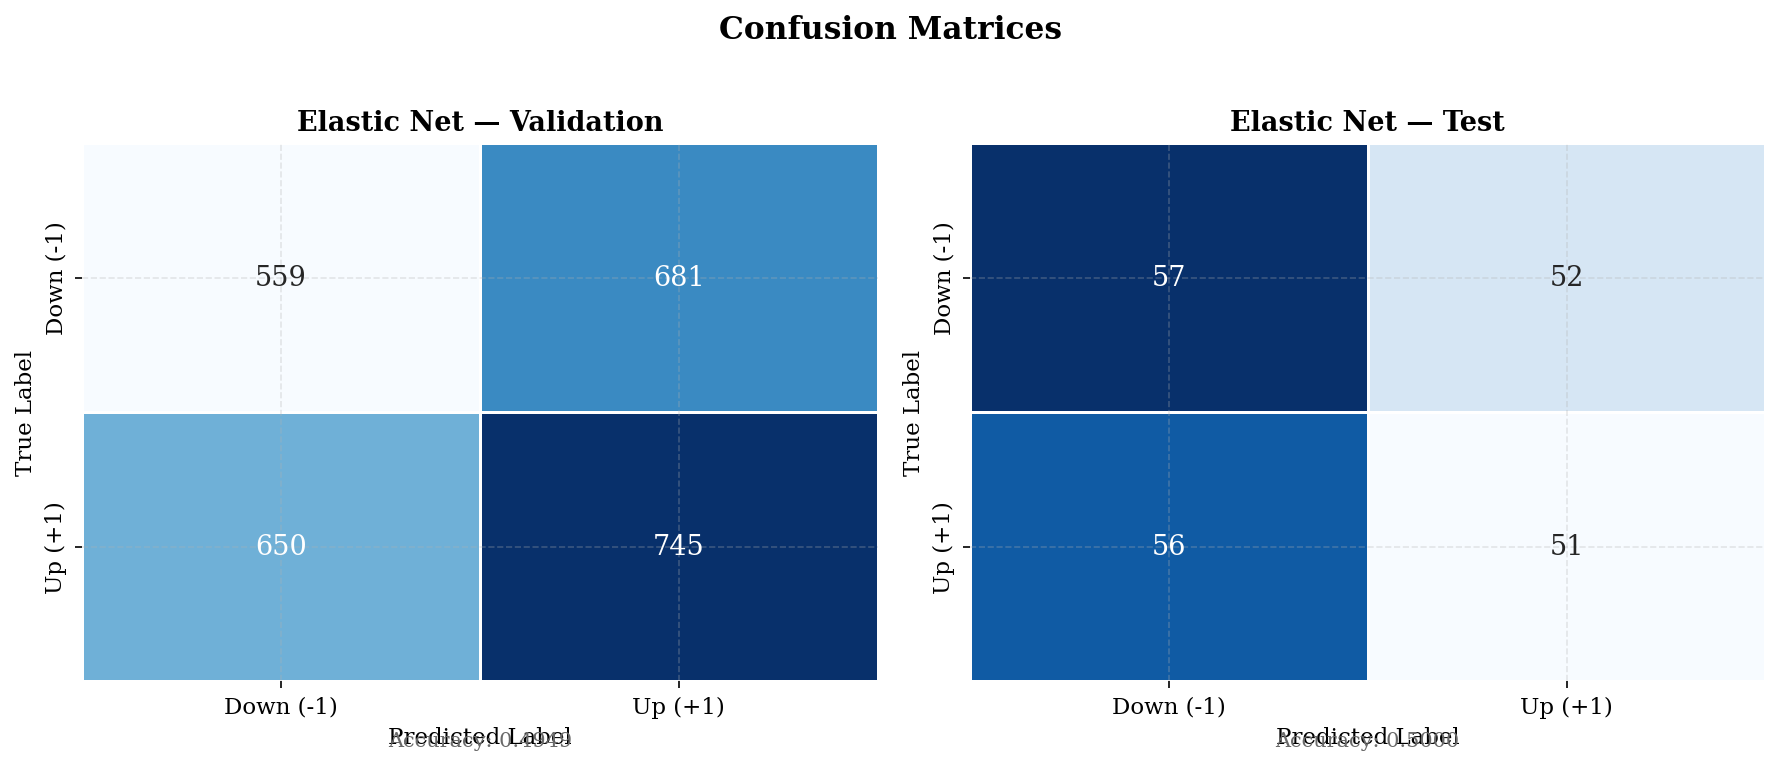

In [13]:
# ============================================================
# Confusion Matrix Heatmaps — Validation and Test
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ["Down (-1)", "Up (+1)"]

for ax, y_true, y_pred, title in [
    (axes[0], y_val.values,  pred_val,  "Validation"),
    (axes[1], y_test.values, pred_test, "Test"),
]:
    cm = confusion_matrix(y_true, y_pred, labels=[-1, 1])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels, yticklabels=labels,
        linewidths=0.5, ax=ax, cbar=False,
        annot_kws={"size": 13},
    )
    ax.set_title(f"Elastic Net — {title}", fontweight="bold")
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    acc = accuracy_score(y_true, y_pred)
    ax.text(0.5, -0.12, f"Accuracy: {acc:.4f}", transform=ax.transAxes,
            ha="center", fontsize=10, color="dimgray")

plt.suptitle("Confusion Matrices", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 14. Rolling Accuracy Over Time

60-day rolling accuracy on the test set shows whether the model's directional skill is stable across different market regimes.

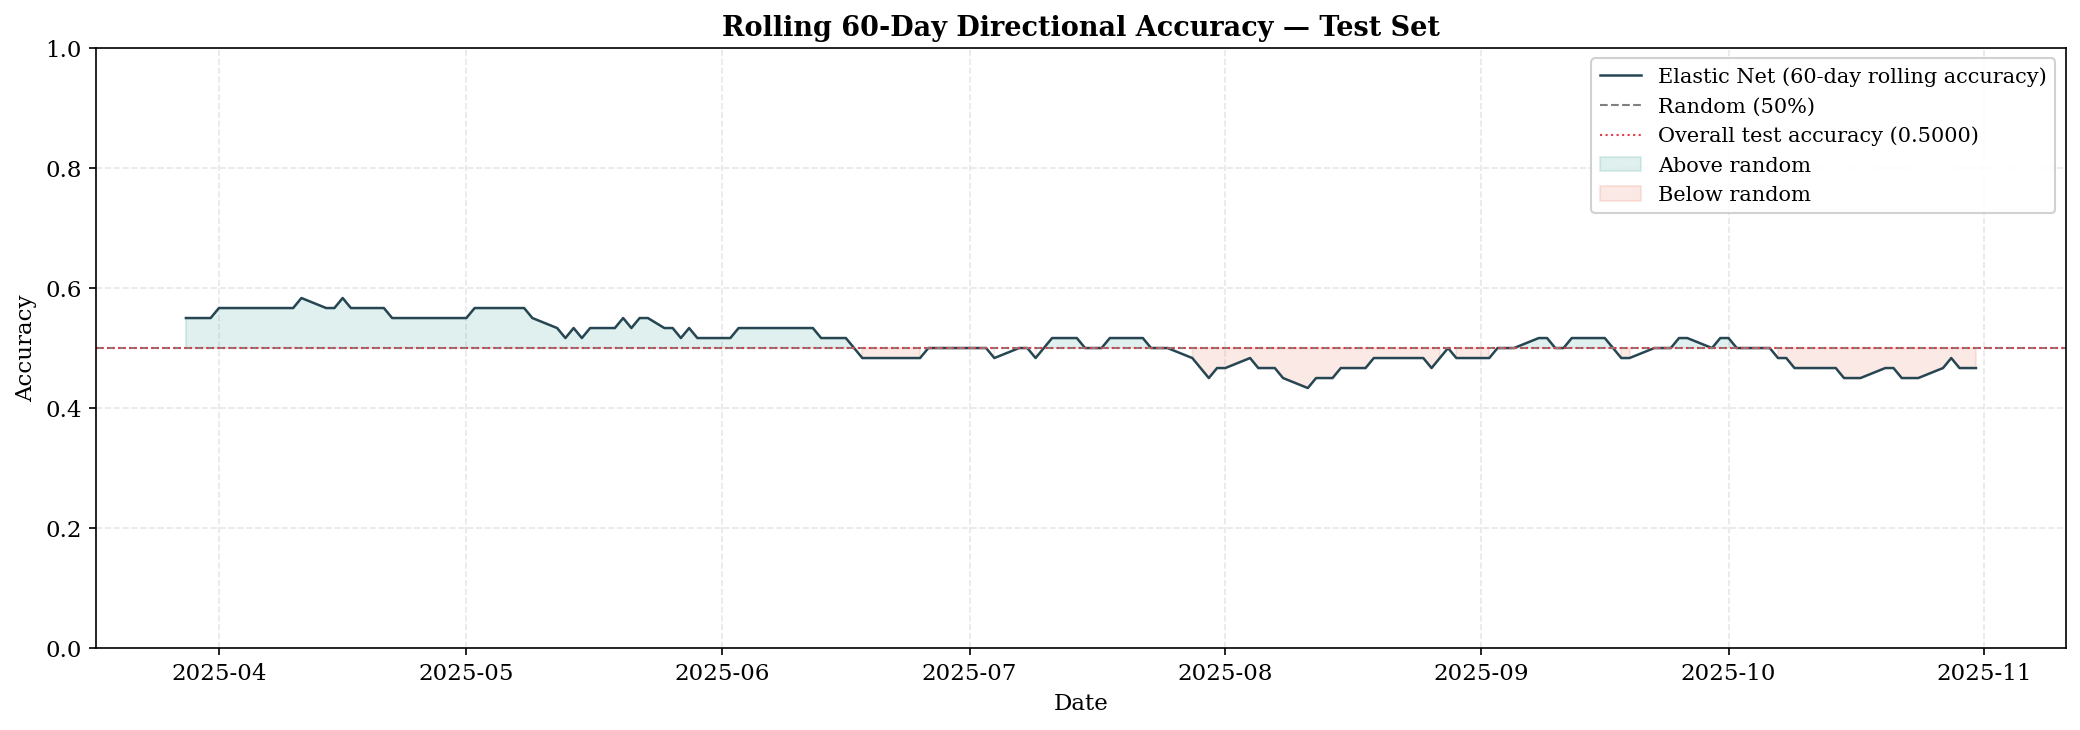

In [14]:
# ============================================================
# Rolling Accuracy Over Time (Test Set)
# ============================================================
roll_window = 60  # trading days

correct = (pred_test == y_test.values).astype(int)
roll_acc = pd.Series(correct, index=y_test.index).rolling(roll_window).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(roll_acc.index, roll_acc.values, color=C_PALETTE['model'], lw=1.2,
        label=f"Elastic Net ({roll_window}-day rolling accuracy)")
ax.axhline(0.5, color="gray", lw=1, ls="--", label="Random (50%)")
ax.axhline(test_metrics["accuracy"], color=C_PALETTE['accent'], lw=1, ls=":",
           label=f"Overall test accuracy ({test_metrics['accuracy']:.4f})")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values >= 0.5,
                alpha=0.15, color=C_PALETTE['up'], label="Above random")
ax.fill_between(roll_acc.index, 0.5, roll_acc.values,
                where=roll_acc.values < 0.5,
                alpha=0.15, color=C_PALETTE['down'], label="Below random")
ax.set_title(f"Rolling {roll_window}-Day Directional Accuracy — Test Set",
             fontweight="bold")
ax.set_ylabel("Accuracy")
ax.set_xlabel("Date")
ax.set_ylim(0, 1)
ax.legend(loc="upper right", framealpha=0.9)
plt.tight_layout()
plt.show()

## 15. Predicted vs Actual Direction

Bar chart comparing how often the model predicts Up and Down versus the true class distribution. Large divergence here can indicate class imbalance or prediction bias.

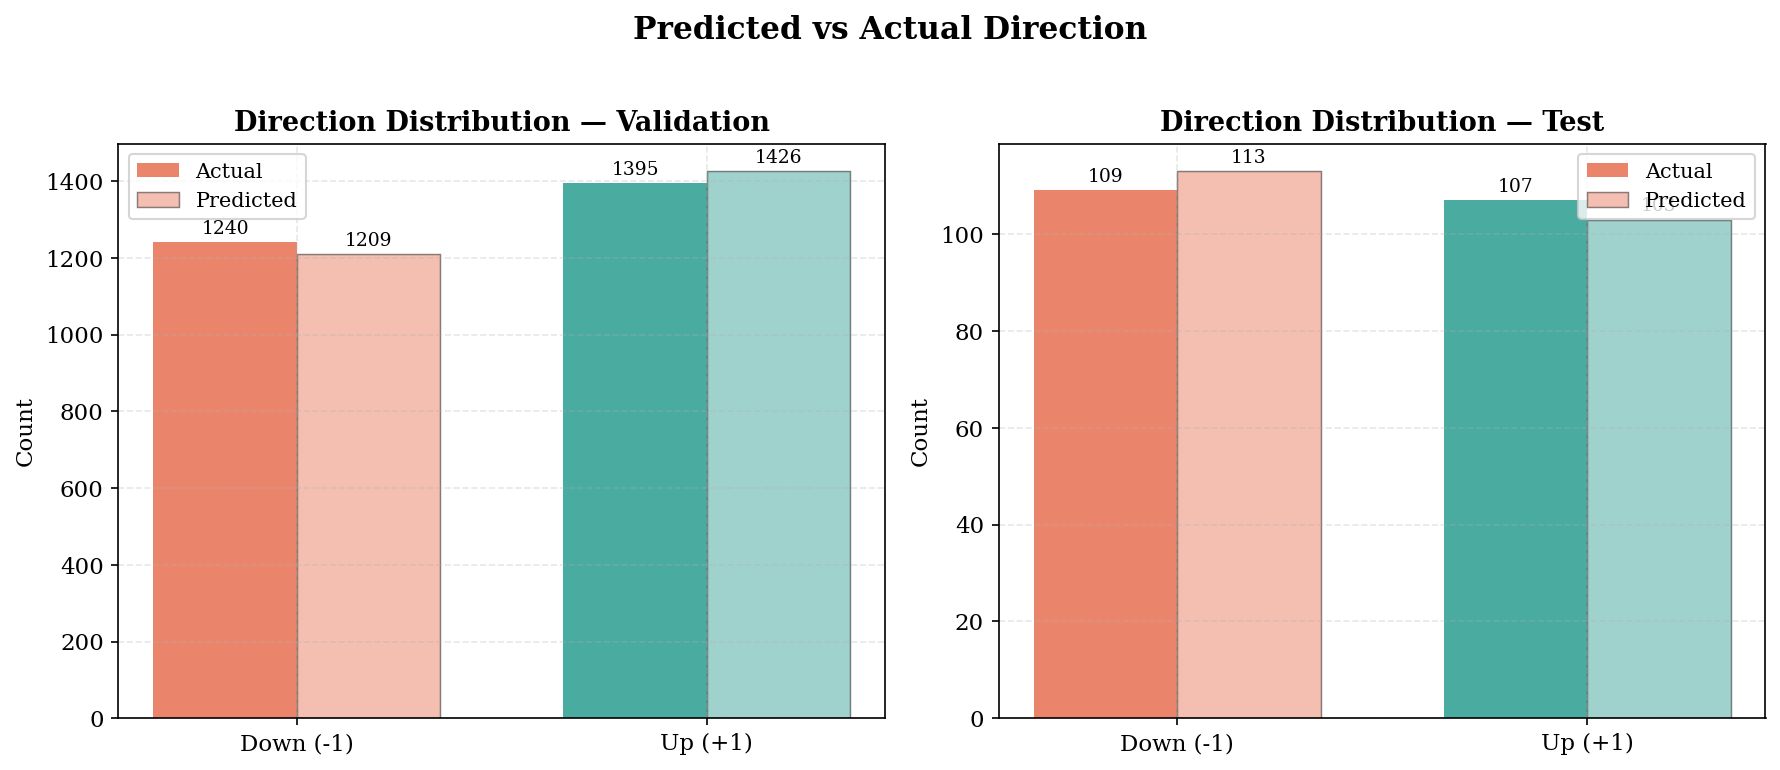

In [15]:
# ============================================================
# Predicted vs Actual Direction Distribution
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_true, y_pred, title in [
    (axes[0], y_val.values,  pred_val,  "Validation"),
    (axes[1], y_test.values, pred_test, "Test"),
]:
    cats = ["Down (-1)", "Up (+1)"]
    actual_counts = [(y_true == -1).sum(), (y_true == 1).sum()]
    pred_counts   = [(y_pred == -1).sum(), (y_pred == 1).sum()]

    x = np.arange(len(cats))
    w = 0.35
    b1 = ax.bar(x - w/2, actual_counts, w, label="Actual",
                color=[C_PALETTE['down'], C_PALETTE['up']], alpha=0.85)
    b2 = ax.bar(x + w/2, pred_counts,   w, label="Predicted",
                color=[C_PALETTE['down'], C_PALETTE['up']], alpha=0.45,
                edgecolor='black', linewidth=0.7)

    for bar in list(b1) + list(b2):
        ax.annotate(f"{int(bar.get_height())}",
                    xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    xytext=(0, 4), textcoords="offset points",
                    ha="center", fontsize=9)

    ax.set_title(f"Direction Distribution — {title}", fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(cats)
    ax.set_ylabel("Count")
    ax.legend()

plt.suptitle("Predicted vs Actual Direction", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 16. Top Feature Coefficients

The 20 features with the largest absolute logistic regression coefficients. Positive coefficients push the model toward predicting Up; negative toward Down. Elastic Net regularisation shrinks many of the 930+ coefficients to exactly zero, retaining only the most informative predictors.

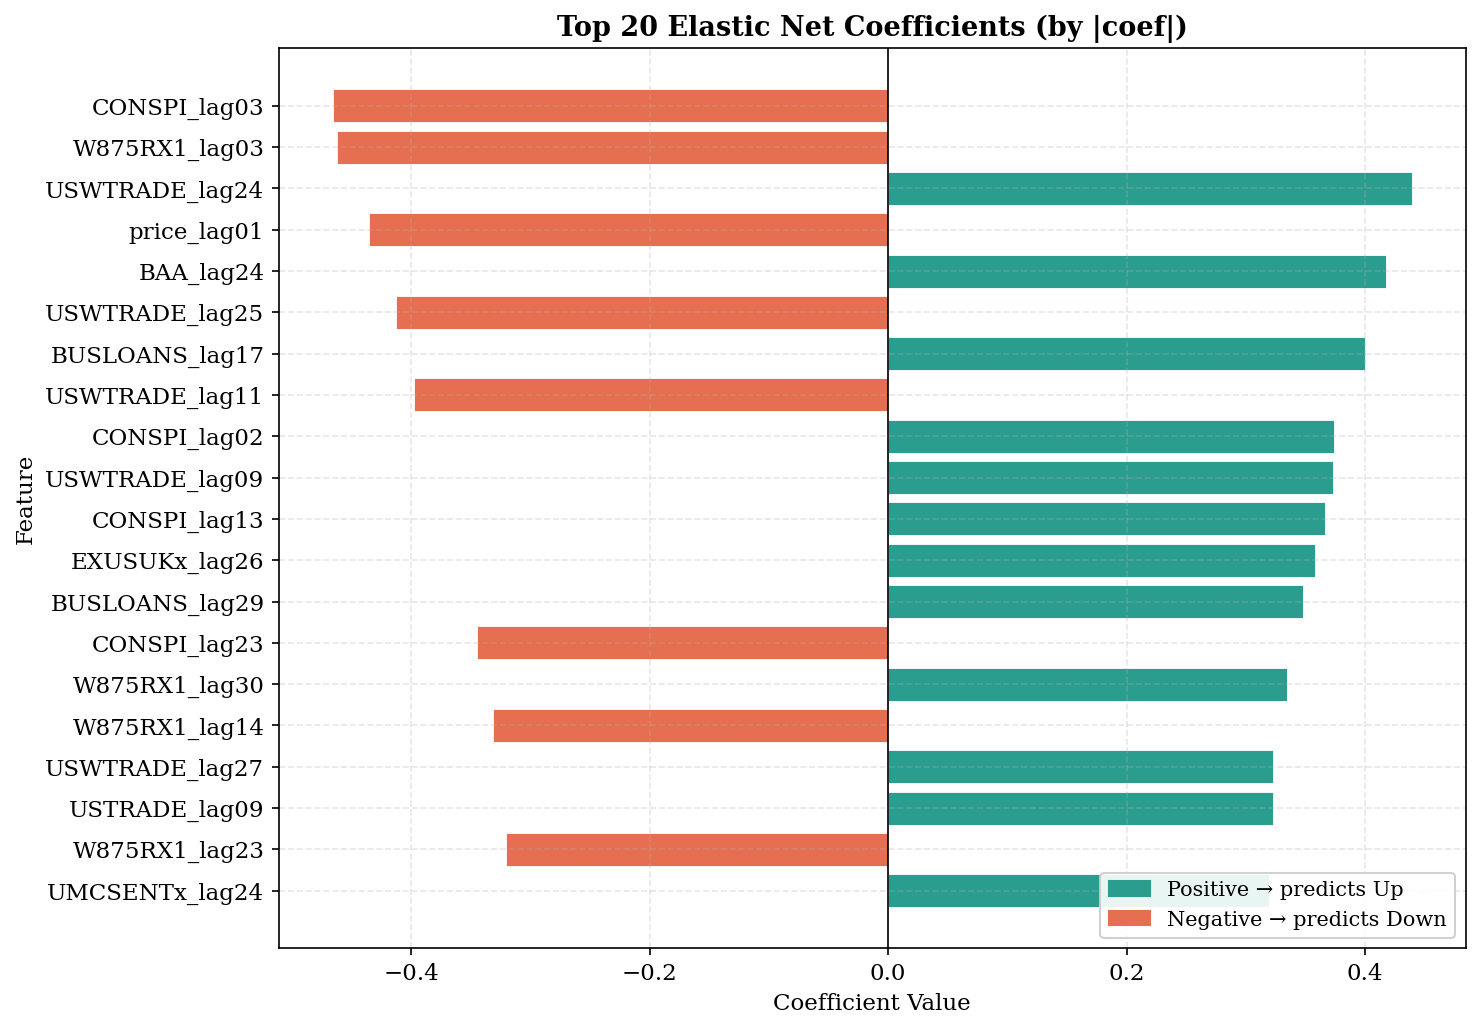


Top 20 features:
       feature      coef
  CONSPI_lag03 -0.465499
 W875RX1_lag03 -0.462292
USWTRADE_lag24  0.439036
   price_lag01 -0.434905
     BAA_lag24  0.417407
USWTRADE_lag25 -0.413008
BUSLOANS_lag17  0.399987
USWTRADE_lag11 -0.397627
  CONSPI_lag02  0.373753
USWTRADE_lag09  0.372900
  CONSPI_lag13  0.366770
 EXUSUKx_lag26  0.358408
BUSLOANS_lag29  0.348352
  CONSPI_lag23 -0.344297
 W875RX1_lag30  0.334804
 W875RX1_lag14 -0.330984
USWTRADE_lag27  0.323143
 USTRADE_lag09  0.322726
 W875RX1_lag23 -0.320106
UMCSENTx_lag24  0.319427


In [16]:
# ============================================================
# Top 20 Feature Coefficients by Absolute Magnitude
# ============================================================
coef_df = model.coef_table(top_n=20)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [C_PALETTE['up'] if c > 0 else C_PALETTE['down']
          for c in coef_df["coef"]]
ax.barh(coef_df["feature"][::-1], coef_df["coef"][::-1],
        color=colors[::-1], edgecolor="white", linewidth=0.4)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Top 20 Elastic Net Coefficients (by |coef|)",
             fontweight="bold")
ax.set_xlabel("Coefficient Value")
ax.set_ylabel("Feature")

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=C_PALETTE['up'],   label="Positive → predicts Up"),
    Patch(color=C_PALETTE['down'], label="Negative → predicts Down"),
], loc="lower right", framealpha=0.9)

plt.tight_layout()
plt.show()

print("\nTop 20 features:")
print(coef_df.to_string(index=False))

## 17. CV Accuracy vs Regularisation Strength

Shows how cross-validated accuracy varies with the regularisation parameter `C` (at the best `l1_ratio`). Higher `C` = less regularisation.

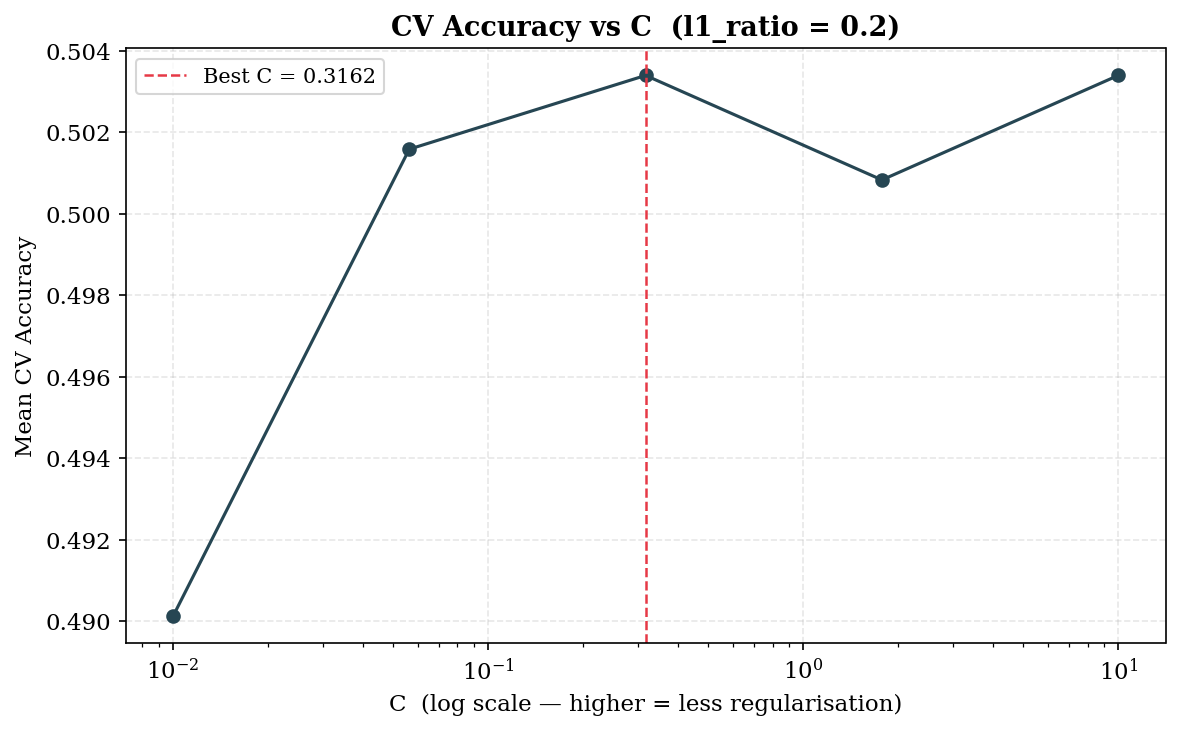

In [17]:
# ============================================================
# CV Accuracy vs C (at best l1_ratio)
# ============================================================
cv_df  = pd.DataFrame(model.cv_results_)
best_l1 = model.best_params_["l1_ratio"]
df_plot = cv_df[cv_df["l1_ratio"] == best_l1].sort_values("C")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(df_plot["C"], df_plot["accuracy"], marker="o",
        color=C_PALETTE['model'], lw=1.5, ms=6)
ax.axvline(model.best_params_["C"], color=C_PALETTE['accent'],
           ls="--", lw=1.2, label=f"Best C = {model.best_params_['C']:.4f}")
ax.set_xscale("log")
ax.set_title(f"CV Accuracy vs C  (l1_ratio = {best_l1})", fontweight="bold")
ax.set_xlabel("C  (log scale — higher = less regularisation)")
ax.set_ylabel("Mean CV Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

## 19. ROC Curve — Validation and Test

The ROC curve plots the True Positive Rate (recall for Up) against the False Positive Rate at every decision threshold. The diagonal represents a random classifier. AUC closer to 1.0 indicates better discrimination; AUC near 0.5 confirms near-random performance.

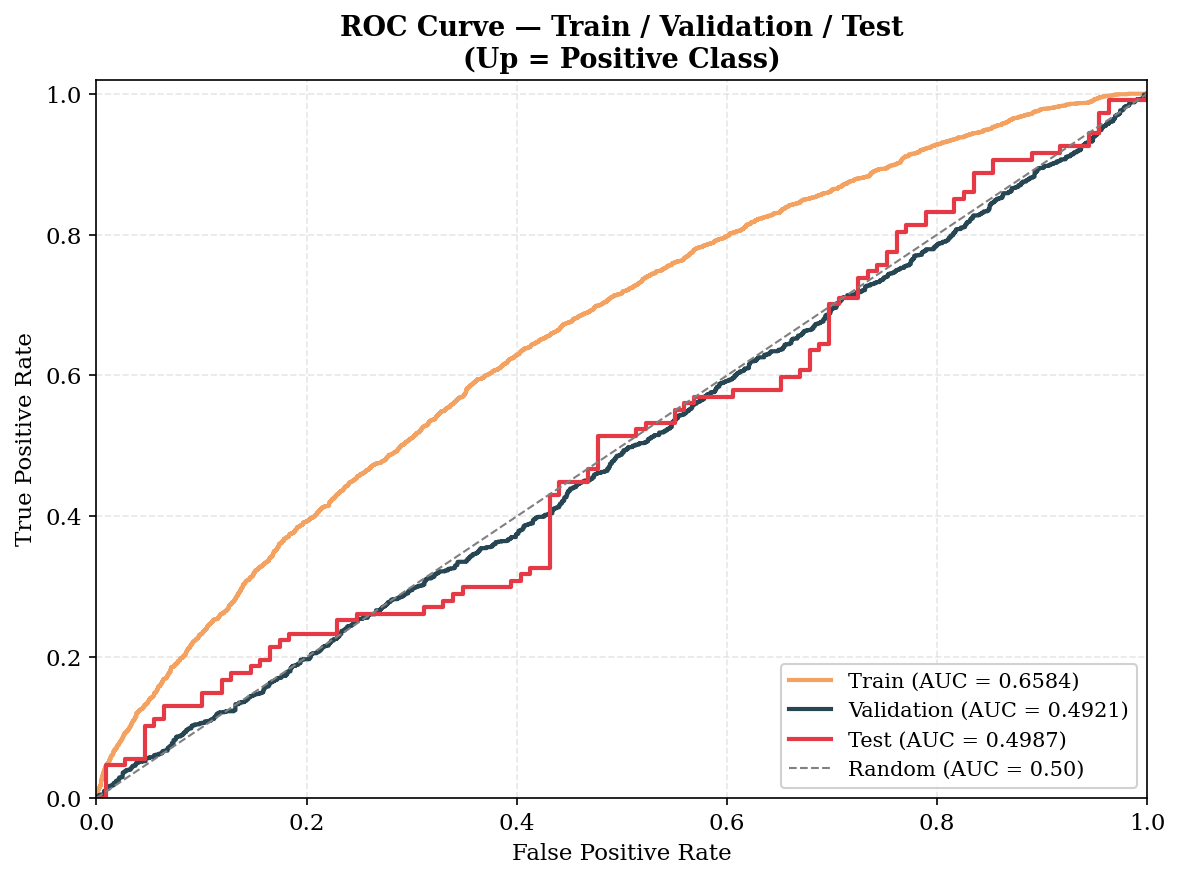

Split             AUC    Accuracy
───────────────────────────────────
Train          0.6584      0.6149
Validation     0.4921      0.4949
Test           0.4987      0.5000


In [18]:
# ============================================================
# ROC Curves — Train, Validation, and Test
# ============================================================
from sklearn.metrics import roc_curve

# Compute train predictions (not generated during training)
prob_train = model.predict_proba(X_train)
pred_train = model.predict(X_train)

splits = [
    ("Train",      y_train.values, prob_train, "#f4a261"),   # orange
    ("Validation", y_val.values,   prob_val,   C_PALETTE['model']),  # dark teal
    ("Test",       y_test.values,  prob_test,  C_PALETTE['accent']), # red
]

fig, ax = plt.subplots(figsize=(8, 6))

for label, y_true, y_prob, color in splits:
    fpr, tpr, _ = roc_curve(y_true, y_prob, pos_label=1)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f"{label} (AUC = {auc:.4f})")

ax.plot([0, 1], [0, 1], color="gray", lw=1, ls="--", label="Random (AUC = 0.50)")

ax.set_title("ROC Curve — Train / Validation / Test\n(Up = Positive Class)",
             fontweight="bold")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.legend(loc="lower right", framealpha=0.9)
plt.tight_layout()
plt.show()

# Print AUC summary
print(f"{'Split':<12} {'AUC':>8}  {'Accuracy':>10}")
print("─" * 35)
for label, y_true, y_prob, _ in splits:
    y_pred = model.predict(X_train if label == "Train" else
                           X_val   if label == "Validation" else X_test)
    print(f"{label:<12} {roc_auc_score(y_true, y_prob):>8.4f}  "
          f"{accuracy_score(y_true, y_pred):>10.4f}")

## 18. Save Model

In [19]:
# ============================================================
# Save trained model to disk
# ============================================================
model.save("elasticnet_wti_direction.pkl")
print("Model saved to elasticnet_wti_direction.pkl")

Model saved to elasticnet_wti_direction.pkl
